# Time Series Forecasting - Team 8

In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display

# Pre-process Dataset

In [ ]:
# Manually download dataset into /docs
# Check files/ File path
DOCS_PATH = "/content/docs"

print("Files in docs folder:", os.listdir(DOCS_PATH))

TRAIN_PATH = os.path.join(DOCS_PATH, "train.parquet")
TEST_PATH = os.path.join(DOCS_PATH, "test.parquet")

# Lazy load
train_df = pl.scan_parquet(TRAIN_PATH)
test_df = pl.scan_parquet(TEST_PATH)

# Print schema
print("Schema:")
print(test_df.schema)

# Get shape (forces minimal computation)
print("Train shape:", train_df.select(pl.count()).collect())
print("Test shape:", test_df.select(pl.count()).collect())
# Preview data (only loads small sample)
display(train_df.head(5).collect())
display(test_df.head(5).collect())

Files in docs folder: ['train.parquet', 'test.parquet']
Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Flo

/tmp/ipykernel_36972/1005924137.py:16: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(test_df.schema)
/tmp/ipykernel_36972/1005924137.py:19: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Train shape:", train_df.select(pl.count()).collect())


Train shape: shape: (1, 1)
┌─────────┐
│ count   │
│ ---     │
│ u32     │
╞═════════╡
│ 5337414 │
└─────────┘
Test shape: shape: (1, 1)
┌─────────┐
│ count   │
│ ---     │
│ u32     │
╞═════════╡
│ 1447107 │
└─────────┘


/tmp/ipykernel_36972/1005924137.py:20: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Test shape:", test_df.select(pl.count()).collect())


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [ ]:
train_df = (
    pl.scan_parquet(TRAIN_PATH)
    .sort(["code", "sub_code", "sub_category", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

/tmp/ipykernel_36972/3781260164.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  train_df = train_df.collect(streaming=True)


In [ ]:
num_cols = [col for col in train_df.columns if col not in ["code", "ts_index"]]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over("code")
    .alias(col)
    for col in num_cols
])

# Median imputation
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over("code"))
    .alias(col)
    for col in num_cols
])

Summary Statistics

In [ ]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061604  ┆ 2.323426  ┆

Feature Distributions

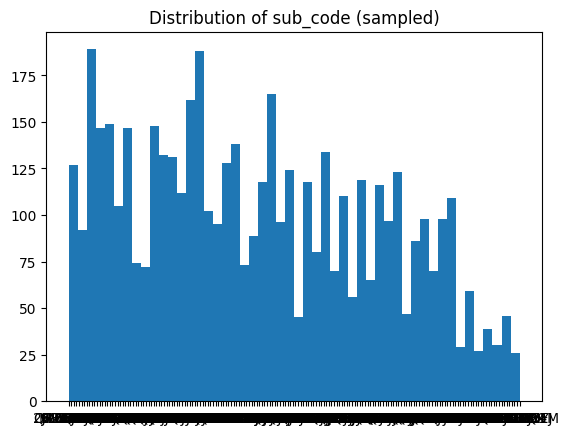

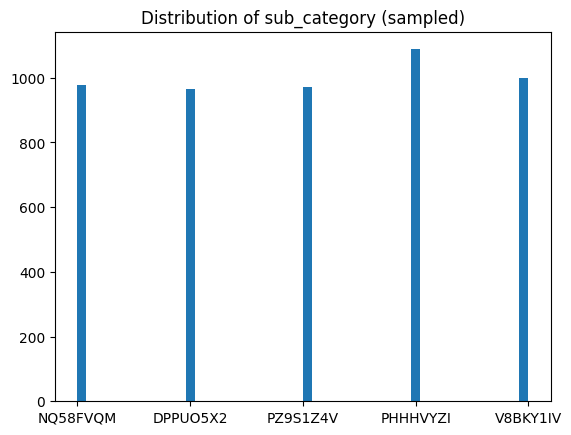

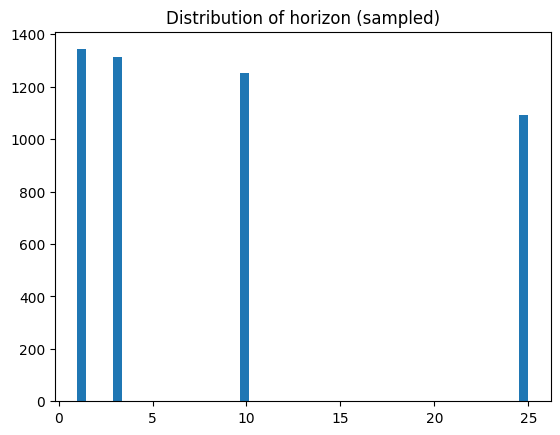

In [ ]:
sample_df = train_df.select(num_cols[1:4]).sample(5000)

for col in num_cols[1:4]:
    values = sample_df[col].to_numpy()

    plt.figure()
    plt.hist(values, bins=50)
    plt.title(f"Distribution of {col} (sampled)")
    plt.show()

Volatility Check

In [ ]:
# Rolling Volatility
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_std(window_size=10)
    .over("code")
    .alias("y_volatility")
])

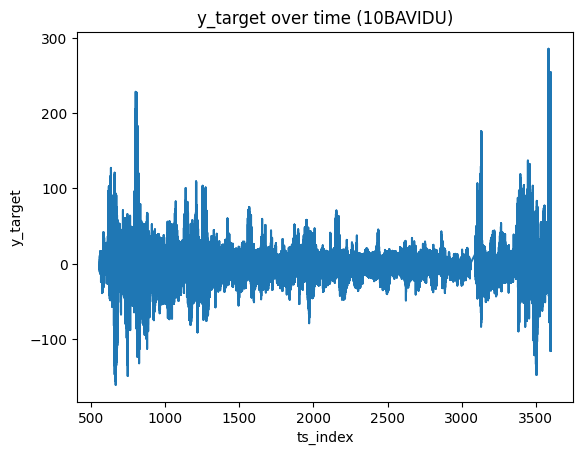

In [ ]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [ ]:
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_mean(window_size=10)
    .over("code")
    .alias("y_rolling_mean")
])
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""1HEMHZK2__J7UUOGYG__V8BKY1IV__…","""1HEMHZK2""","""J7UUOGYG""","""V8BKY1IV""",25.0,1944,63.0,15.499859,8.722259,4.769919,2.421972,0.49025,13.659497,0.0004,0.005336,0.000427,0.009399,0.03688,1.833861,0.046523,0.020177,0.000247,0.000575,0.000945,0.006756,0.008717,0.007171,0.059296,-13.362687,-0.867541,-8.961212,-2.299797,0.036797,2.161286,1.708473,1.935112,0.011964,…,6294.569842,18930.638233,254698.895629,426309.531828,13356.6733,0.000461,10007.455852,6.904485,14987.058711,706.116414,41.211264,0.131114,2.491327,0.112918,0.831227,1.265393,1.013671,-0.280496,-1.543594,-3.92339,3.241402,0.234963,0.218812,-0.000717,-0.000158,-0.001012,-0.000076,-0.001983,-0.000089,0.011282,1.117884,0.027937,2.0,-0.005465,1.4195e6,0.00221,-0.001132
"""WH61ASEA__1IHYTAPJ__NQ58FVQM__…","""WH61ASEA""","""1IHYTAPJ""","""NQ58FVQM""",1.0,2141,17.0,12.194439,11.647412,14.082887,7.562223,1.837962,10.706029,0.021191,0.000322,0.000038,0.000223,0.102496,0.155497,0.720554,0.167917,1.420571,4.967674,0.184912,7.206784,33.840558,45.589069,6.313512,0.498077,-0.366864,-0.065358,-43.636054,0.033244,0.011642,0.014261,0.704764,2.666493,…,0.326238,0.0,8235.571587,155416.006041,5794.188546,0.0,77944.669961,0.204285,0.0,0.0,0.00349,261.42583,571.772101,16.730106,0.099691,0.005797,0.004688,-5.409433,-4.158525,-0.91139,0.049187,0.172998,8.884823,-2.791206,-0.296494,-0.234123,-1.432402,-0.089355,-0.182299,-0.291104,1.765092,0.075339,0.0,0.111667,4.174648,1.125741,1.031831
"""6LB028J8__DYJUJX3J__PHHHVYZI__…","""6LB028J8""","""DYJUJX3J""","""PHHHVYZI""",1.0,2146,200.0,11.682676,6.330384,12.504695,5.447049,14.005579,4.057169,0.001569,0.00602,0.004565,0.000127,0.219869,2.920117,-0.002532,0.002296,0.001438,0.002441,0.027779,0.39647,0.335229,0.009791,0.013487,-14.02032,0.072481,-151.182342,-1.622403,0.39294,0.040561,0.0128,0.042535,0.022698,…,0.507463,18355.169466,100530.776849,1.4640e6,1.6136e6,0.042372,506928.081895,7.806336,847.701002,19872.308519,0.140658,7.157991,0.524049,13.3264,1.88344,2.458149,2.386965,-6.785188,-0.169589,-0.110549,0.127421,1.121801,10.807233,-0.000211,-0.000458,-0.011916,-0.014204,-0.016262,-0.000436,-0.012424,0.201878,2.801375,9.0,0.045761,1149.093059,0.078383,0.025007
"""VFWIFJPS__5MOIDROW__PZ9S1Z4V__…","""VFWIFJPS""","""5MOIDROW""","""PZ9S1Z4V""",25.0,755,56.0,10.857845,3.691018,16.077477,7.656796,8.639506,15.090252,0.006751,0.000245,0.000182,0.00038,1.587333,1.137854,0.002213,0.040901,0.002872,0.00217,0.002121,0.003539,0.11374,0.063387,0.006605,-22.731387,-9.998739,-8.644069,0.0,8.295082,0.327043,0.191496,3.925548,0.03313,…,1117.125697,70298.380473,93671.533917,8178.906184,9224.055205,0.017996,22947.720181,0.361104,1698.105156,71.551354,2.367268,0.675544,0.096849,2.000701,2.185058,1.452954,1.698513,-0.381719,-0.096037,-0.115985,2.012033,5.122125,0.311418,-0.00007,-0.003464,-0.000106,-0.00009,-0.000131,-0.000789,0.007581,0.060864,1.88547,1.0,0.016519,520113.902814,0.00626,0.0005
"""MRV5UON2__R571RU17__

In [ ]:
# Feature Importance Correlation
corr_df = train_df.select(
    [pl.corr(col, "y_target").alias(col) for col in num_cols[:10]]
)

print(corr_df)

shape: (1, 10)
┌─────┬──────────┬──────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id  ┆ sub_code ┆ sub_category ┆ horizon   ┆ … ┆ feature_c ┆ feature_d ┆ feature_e ┆ feature_f │
│ --- ┆ ---      ┆ ---          ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64 ┆ f64      ┆ f64          ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════╪══════════╪══════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NaN ┆ NaN      ┆ NaN          ┆ -0.018719 ┆ … ┆ 0.00057   ┆ 0.000097  ┆ -0.000574 ┆ -0.000027 │
└─────┴──────────┴──────────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


# Baseline Model

First, the necessary libraries and modules are imported for the creation of this base model, which includes using HistGradientBoostingRegressor.

In [ ]:
import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

SEED = 42

print(train_df.shape)
train_df.head()

(5337414, 96)


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",3.0,3531,141.0,3.475385,15.13462,3.265031,10.380979,8.83843,2.01938,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,0.670754,0.017167,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3531,134.0,12.707232,11.597299,6.034944,13.931955,9.418021,16.584339,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,5.601772,0.010329,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",25.0,3531,119.0,11.262484,1.45387,6.210146,8.292425,1.175443,15.234003,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,8.425576,0.016712,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3531,143.0,2.296699,1.939771,15.459024,8.540194,16.673829,14.100175,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,-2.795824,0.032189,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3532,142.0,4.631196,2.84

Next, we define the dataset with focus on features, weight and target.

In [ ]:
ID = "id"
CODE = "code"
SUBCODE = "sub_code"
SUBCATEGORY = "sub_category"
HORIZON = "horizon"
TS_INDEX = "ts_index"
TARGET = "y_target"
WEIGHT = "weight"
VOLATILITY = "y_volatility"
ROLLING_MEAN = "y_rolling_mean"

SAMPLE_FRAC = 0.01

train_df = (
    train_df
    .sample(fraction=SAMPLE_FRAC, seed=SEED)
    .sort(TS_INDEX)
)

FEATURES = [c for c in train_df.columns if c not in [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX, TARGET, WEIGHT, VOLATILITY, ROLLING_MEAN]]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)
w = train_df.select(WEIGHT)

Time-series validation splits are then defined to prevent data leakage.

---



In [ ]:
N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

splits = list(tscv.split(X))

print(f"Number of splits: {len(splits)}")

Number of splits: 5


Furthermore, we determine weighted error metric using a flexible weighted RMSE implementation.

In [ ]:
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))

def weighted_rmse(y_true, y_pred, w) -> float:

    denom = np.sum(w * y_true ** 2)
    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    val = 1.0 - clipped
    return float(np.sqrt(val))

def compute_weights(df):

    return np.ones(len(df))

Most importantly, we train the baseline model. We are using the tree based model, HistGradientBoostingRegressor.

In [ ]:
def train_baseline_hgbr(X, y, splits):

    oof_predictions = np.zeros(len(X))

    X_np = X.to_numpy()
    y_np = y.to_numpy()
    w_np = w.to_numpy().flatten()

    for fold, (train_idx, val_idx) in enumerate(splits):

        print(f"\n===== Fold {fold+1} =====")

        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]
        y_train = y_np[train_idx]
        y_val   = y_np[val_idx].flatten()
        w_val   = w_np[val_idx]

        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=SEED
        )

        model.fit(X_train, y_train)

        preds = model.predict(X_val)
        oof_predictions[val_idx] = preds

        del model, X_train, X_val
        gc.collect()

    return oof_predictions

Adding compute functions - feature experiment validation support.

In [ ]:
def compute_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def compute_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_absolute_error(y_true, y_pred)

Use rmse and mae to compute fold metrics - feature experiment validation support.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_fold_metrics(y_true, y_pred, splits):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    fold_scores = []

    for fold, (_, val_idx) in enumerate(splits):
        y_val = y_true[val_idx]
        y_pred_val = y_pred[val_idx]

        # Calculate MSE and then take the square root for RMSE
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        mae = mean_absolute_error(y_val, y_pred_val)

        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})

    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae = np.mean([f["mae"] for f in fold_scores])

    return fold_scores, mean_rmse, mean_mae

Adding compute functions - feature experiment validation support.

In [ ]:
def compute_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def compute_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_absolute_error(y_true, y_pred)

Use rmse and mae to compute fold metrics - feature experiment validation support.

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_fold_metrics(y_true, y_pred, splits):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    fold_scores = []

    for fold, (_, val_idx) in enumerate(splits):
        y_val = y_true[val_idx]
        y_pred_val = y_pred[val_idx]

        # Calculate MSE and then take the square root for RMSE
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        mae = mean_absolute_error(y_val, y_pred_val)

        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})

    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae = np.mean([f["mae"] for f in fold_scores])

    return fold_scores, mean_rmse, mean_mae

Display the folds using rmse and mae - feature experiment validation support.

In [ ]:
oof_preds, _ = train_baseline_hgbr(X, y, splits)

fold_scores, mean_rmse, mean_mae = compute_fold_metrics(y, oof_preds, splits)

print("Fold-wise scores:")
for f in fold_scores:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")

print(f"\nMean RMSE: {mean_rmse:.4f}, Mean MAE: {mean_mae:.4f}")


===== Fold 1 =====
Fold RMSE: 0.80150

===== Fold 2 =====
Fold RMSE: 0.80138

===== Fold 3 =====
Fold RMSE: 0.78501

===== Fold 4 =====
Fold RMSE: 0.76353

===== Fold 5 =====
Fold RMSE: 0.79021
Fold-wise scores:
Fold 1 - RMSE: 8.2882, MAE: 6.7668
Fold 2 - RMSE: 8.3035, MAE: 6.7227
Fold 3 - RMSE: 8.0454, MAE: 6.5818
Fold 4 - RMSE: 8.0659, MAE: 6.5125
Fold 5 - RMSE: 7.9839, MAE: 6.5745

Mean RMSE: 8.1374, Mean MAE: 6.6317


Here we obtain the 'error magnitude' or RMSE of each split. This shows how well the base model learns.

In [ ]:
oof_preds, fold_scores = train_baseline_hgbr(X,y,splits)
print("\n======================")
print("Baseline Results")
print("======================")
print("Fold Scores:", fold_scores)
print("Mean Score:", np.mean(fold_scores))


===== Fold 1 =====
Fold RMSE: 0.80150

===== Fold 2 =====
Fold RMSE: 0.80138

===== Fold 3 =====
Fold RMSE: 0.78501

===== Fold 4 =====
Fold RMSE: 0.76353

===== Fold 5 =====
Fold RMSE: 0.79021

Baseline Results
Fold Scores: [0.8015042892735742, 0.8013790508577511, 0.7850101797658899, 0.7635276627468487, 0.7902137341629638]
Mean Score: 0.7883269833614055


Next, we evaluate the model using competition metric.
We shall perform the same operations on test_df as done on train_df. The first step is to preprocess the test data.

In [ ]:
test_df_processed = (
    pl.scan_parquet(TEST_PATH)
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
    .collect(streaming=True)
)

exclude_cols_for_num_processing = [ID, CODE, SUBCODE, SUBCATEGORY, TS_INDEX, TARGET]

test_feature_cols = [
    col for col in test_df_processed.columns
    if col not in exclude_cols_for_num_processing and test_df_processed[col].dtype.is_numeric()
]

#Forward fill
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(CODE)
    .alias(col)
    for col in test_feature_cols
])

#Median imputation
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over(CODE))
    .alias(col)
    for col in test_feature_cols
])

#Rolling Volatility
test_df_processed = test_df_processed.with_columns([
    pl.col(TARGET)
    .rolling_std(window_size=10)
    .over(CODE)
    .alias("y_volatility")
])

#Rolling Mean
test_df_processed = test_df_processed.with_columns([
    pl.col(TARGET)
    .rolling_mean(window_size=10)
    .over(CODE)
    .alias("y_rolling_mean")
])

print("Processed Test DataFrame Head:")
display(test_df_processed.head())

print("\nProcessed Test DataFrame Schema:")
print(test_df_processed.schema)

Processed Test DataFrame Head:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_volatility,y_rolling_mean
str,str,str,str,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",25,4175,185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",1,4175,210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",10,4175,201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3,4175,208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0,null,null
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3,4176,207.0,14.844531,1.652745,3.9592


Processed Test DataFrame Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Float64, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float64,

Secondly, we must select our targets & features for testing and preview the test.

In [ ]:
X_test = test_df_processed.select(FEATURES)
y_test = test_df_processed.select(TARGET)

print("\nX_test Head:")
display(X_test.head())
print("\ny_test Head:")
display(y_test.head())


X_test Head:


feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,feature_af,feature_ag,feature_ah,feature_ai,feature_aj,feature_ak,feature_al,feature_am,feature_an,feature_ao,feature_ap,feature_aq,feature_ar,feature_as,feature_at,feature_au,feature_av,feature_aw,feature_ax
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,0.047637,172.652652,6.930192,413.579857,8.64366,0.034237,0.033176,0.084474,0.0,0.0,0.0,0.0,0.0
207.0,14.844531,1.652745,3.959252,4.966838,3.946401,10.636208,0.001842,0.000218,0.000067,0.000089,3.230579,0.646894,2.057089,4.393155,0.691346,11.689794,0.682537,1.410798,47.797074,3.534047,0.939,2.729261,16.588922,59.151639,337.547998,0.024871,0.086148,0.021184,1.559661,0.669681,14.835492,0.548329,11.189002,0.670332,0.025856,0.247064,0.047637,170.136767,6.858543,416.39972,7.583717,0.034262,0.033196,0.084037,0.0,0.0,0.0,0.0,0.0



y_test Head:


horizon
i32
25
1
10
3
3


Finally, we must train the sample data for testing and commence testing to obtain a score based on RMSE.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

print("Training final model on sampled training data...")
final_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    random_state=SEED
)

final_model.fit(X.to_numpy(), y.to_numpy().flatten())

print("\nMaking predictions on test data...")

test_preds = final_model.predict(X_test.to_numpy())

final_weights_test = compute_weights(test_df_processed)

test_score = weighted_rmse(y_test.to_numpy().flatten(), test_preds, final_weights_test)

print(f"\nFinal Test Score (Weighted RMSE): {test_score:.5f}")

Training final model on sampled training data...

Making predictions on test data...

Final Test Score (Weighted RMSE): 0.78628


To conclude with model building, we display the key results in a table.

In [ ]:
import pandas as pd
import numpy as np

results_table = pd.DataFrame({
    "model": ["HistGradientBoosting_Baseline"],
    "mean_cv_score": [np.mean(fold_scores)],
    "std_cv_score": [np.std(fold_scores)],
    "final_test_score": [test_score]
})

print(results_table.to_string(index=False))

                        model  mean_cv_score  std_cv_score  final_test_score
HistGradientBoosting_Baseline       0.788327      0.013954          0.786279


# Feature Engineering

### Lag Features

In [ ]:
# Generate lag features
def generate_lags_polars(df, feature_cols, lag_list, group_col=CODE):
    lag_exprs = []
    for col in feature_cols:
        for lag in lag_list:
            # shift and fill nulls with 0
            lag_exprs.append(
                pl.col(col)
                .shift(lag)
                .over(group_col)
                .fill_null(0)
                .alias(f"{col}_lag_{lag}")
            )
    return df.with_columns(lag_exprs)

# Lag sets to evaluate
lag_sets = [
    [1],
    [1, 2],
    [1, 2, 3],
    [1, 2, 3, 5],
    [1, 2, 3, 5, 10],
    [1, 2, 3, 5, 10, 25]
]

results = []

for lags in lag_sets:
    print(f"\n==== Testing lags: {lags} ====")

    # Generate lag features
    df_lagged = generate_lags_polars(train_df, FEATURES, lags)

    # Select original + lag features
    lag_cols = [f"{col}_lag_{lag}" for col in FEATURES for lag in lags]
    lag_features = [c for c in df_lagged.columns if c in FEATURES or c in lag_cols]

    x_lag = df_lagged.select(lag_features)
    y_lag = df_lagged.select(TARGET)

    # Prepare time series splits
    splits_lag = list(TimeSeriesSplit(n_splits=N_SPLITS).split(x_lag))

    # Train baseline HGBR model
    oof_preds, fold_weighted_rmse = train_baseline_hgbr(x_lag, y_lag, splits_lag)

    # Compute fold-wise metrics
    fold_metrics, mean_rmse, mean_mae = compute_fold_metrics(
        y_lag.to_numpy().flatten(),
        oof_preds.flatten(),
        splits_lag
    )

    results.append({
        "lags": lags,
        "weighted_rmse": np.mean(fold_weighted_rmse),
        "rmse": mean_rmse,
        "mae": mean_mae,
        "fold_metrics": fold_metrics
    })

# Print results
results_df = pd.DataFrame(results)
print("\n=== Lag Feature Evaluation ===")
for res in results:
    print(f"\nLags tested: {res['lags']}")
    for f in res['fold_metrics']:
        print(f"  Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
    print(f"  Mean RMSE: {res['rmse']:.4f}, Mean MAE: {res['mae']:.4f}")


==== Testing lags: [1] ====

===== Fold 1 =====
Fold RMSE: 0.68980

===== Fold 2 =====
Fold RMSE: 0.85160

===== Fold 3 =====
Fold RMSE: 0.77720

===== Fold 4 =====
Fold RMSE: 0.00000

===== Fold 5 =====
Fold RMSE: 0.82710

==== Testing lags: [1, 2] ====

===== Fold 1 =====
Fold RMSE: 0.66731

===== Fold 2 =====
Fold RMSE: 0.89785

===== Fold 3 =====
Fold RMSE: 0.83492

===== Fold 4 =====
Fold RMSE: 0.00000

===== Fold 5 =====
Fold RMSE: 0.83778

==== Testing lags: [1, 2, 3] ====

===== Fold 1 =====
Fold RMSE: 0.69887

===== Fold 2 =====
Fold RMSE: 0.85037

===== Fold 3 =====
Fold RMSE: 0.82128

===== Fold 4 =====
Fold RMSE: 0.00000

===== Fold 5 =====
Fold RMSE: 0.86793

==== Testing lags: [1, 2, 3, 5] ====

===== Fold 1 =====
Fold RMSE: 0.69887

===== Fold 2 =====
Fold RMSE: 0.87821

===== Fold 3 =====
Fold RMSE: 0.78484

===== Fold 4 =====
Fold RMSE: 0.00000

===== Fold 5 =====
Fold RMSE: 0.84005

==== Testing lags: [1, 2, 3, 5, 10] ====

===== Fold 1 =====
Fold RMSE: 0.69887

====

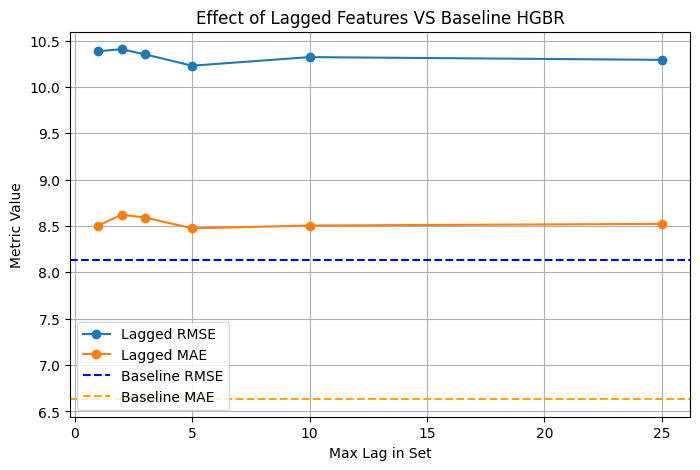

In [ ]:
# Baseline metrics
baseline_rmse = 8.1374
baseline_mae = 6.6317

# Convert lag sets to a representative number (max lag in each set)
max_lags = [max(l) for l in results_df['lags']]

# Metrics
rmse = results_df['rmse']
mae = results_df['mae']

plt.figure(figsize=(8,5))

plt.plot(max_lags, rmse, marker='o', label='Lagged RMSE')
plt.plot(max_lags, mae, marker='o', label='Lagged MAE')
plt.axhline(baseline_rmse, color='blue', linestyle='--', label='Baseline RMSE')
plt.axhline(baseline_mae, color='orange', linestyle='--', label='Baseline MAE')

plt.xlabel('Max Lag in Set')
plt.ylabel('Metric Value')
plt.title('Effect of Lagged Features VS Baseline HGBR')
plt.legend()
plt.grid(True)
plt.show()

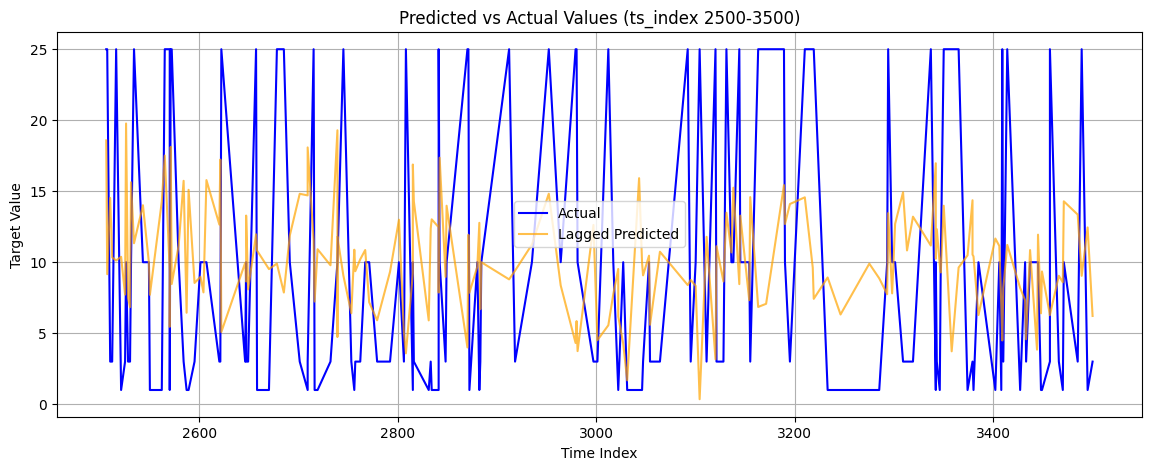

In [ ]:
ts_index = df_lagged.select(TS_INDEX).to_numpy().flatten()
y_actual = y_lag.to_numpy().flatten()
y_pred = oof_preds.flatten()

start_idx = 2500
end_idx = 3500

mask = (ts_index >= start_idx) & (ts_index <= end_idx)

ts_zoom = ts_index[mask]
actual_zoom = y_actual[mask]
pred_lagged_zoom = y_pred[mask]
pred_actual_zoom = y_actual[mask]

plt.figure(figsize=(14,5))
plt.plot(ts_zoom, actual_zoom, label='Actual', color='blue')
plt.plot(ts_zoom, pred_lagged_zoom, label='Lagged Predicted', color='orange', alpha=0.7)
plt.xlabel('Time Index')
plt.ylabel('Target Value')
plt.title(f'Predicted vs Actual Values (ts_index {start_idx}-{end_idx})')
plt.legend()
plt.grid(True)
plt.show()